# `02_distribuicoes.ipynb` — Fidelidade distribucional (Kolmogorov–Smirnov)

**Etapa 5 — Avaliação · notebook 2 de 4**

## Objetivo

Comparar a **distribuição** dos valores reais vs imputados via teste de
**Kolmogorov–Smirnov (KS)**, histogramas e ECDFs. O foco é a patologia clássica de GANs
imputadoras: **compressão de variância** (o gerador regride à média condicional e encolhe
as caudas).

> **Pergunta:** a GAIN preserva a distribuição das variáveis (dispersão, caudas) ou comprime a variância?

## Recapitulação — o achado do PIBIC anterior

O PIBIC 2024–2025 (`Articles/2024_2025_PIBIC_Dannylo_RafaelSanches.pdf`) reportou que a GAN
testada **comprimiu a variância**: o KS rejeitou H₀ (`p < 0.001`) em **todas** as variáveis
— ou seja, a distribuição imputada diferia significativamente da real em todo o painel.
Aqui verificamos se a GAIN deste projeto (condicional, com termo supervisionado `beta`)
melhora esse quadro.

## Como ler o KS (importante)

Para cada variável, aplicamos `ks_2samp(reais, imputados)` **apenas nas células escondidas**
`(M=1, B=0)` — exatamente as posições que o notebook 01 mediu.

- **H₀**: reais e imputados vêm da **mesma** distribuição.
- `KS_stat` = maior distância vertical entre as duas ECDFs (0 = idênticas).
- **`p` baixo (`< 0.05`) → rejeita H₀ → as distribuições DIFEREM → ruim** para imputação.
- **`p` alto → não rejeita → distribuições consistentes → bom.** É o que queremos.
- **Ressalva de poder:** aqui `n` por variável é pequeno (10–54 células, 3 seeds somadas).
  Com `n` baixo o KS tem **pouca potência** — `p` alto pode significar "sem evidência de
  diferença" e não "distribuições idênticas". Por isso reportamos também a razão de
  desvios `sd_ratio = sd(imputado)/sd(real)` (< 1 = compressão), diagnóstico direto e
  independente de `p`.

> KS é **invariante a transformação monótona** aplicada igualmente aos dois lados; logo o
> `KS_stat` na escala física é idêntico ao do espaço normalizado. Trabalhamos na **escala
> original** (interpretável) — mesma das predições persistidas.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

ROOT = Path.cwd()
while not (ROOT / "Data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CODE = ROOT / "Code"
sys.path.insert(0, str(CODE / "3 - Preprocessing"))   # mask_utils
sys.path.insert(0, str(CODE / "4 - Baseline"))        # baseline_utils
import baseline_utils as bu
from mask_utils import generate_artificial_mask

SPLIT_DIR = ROOT / "Data/GoldData/Splited"
MASK_DIR  = ROOT / "Data/GoldData/Masked"
PROC_DIR  = ROOT / "Data/ProcessedData"
BASE_DIR  = ROOT / "Data/BaselineResults"
EVAL_DIR  = ROOT / "Data/EvalResults"

OUT_TAB = CODE / "6 - Evaluation/tabelas"
OUT_FIG = ROOT / "Data/Figures/05_Evaluation"
for d in (OUT_TAB, OUT_FIG):
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 7, 2026]
MISS_RATE = 0.20
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 170)
print("scipy.stats.ks_2samp pronto | escala: original (KS invariante)")

scipy.stats.ks_2samp pronto | escala: original (KS invariante)


## 3. Carregar test real e predições, montar valores por célula escondida

Reconstruímos, para cada método, os pares `(real, imputado)` **em escala original** nas
células escondidas `(M=1, B=0)`, com as **mesmas máscaras** (seeds `[42, 7, 2026]`,
`miss_rate=0.20`) do notebook 01. As predições da GAIN vêm de `Data/EvalResults/` (geradas
no nb01) e as dos 7 baselines de `Data/BaselineResults/`. O valor **real** é o mesmo para
todos os métodos; o **imputado** varia.

In [2]:
df_test        = pd.read_parquet(SPLIT_DIR / "test.parquet")
mask_real_test = pd.read_parquet(MASK_DIR / "mask_real_test.parquet")
scalers          = joblib.load(PROC_DIR / "scalers.pkl")
with open(PROC_DIR / "transform_params.json", encoding="utf-8") as f:
    transform_params = json.load(f)

VARS = list(mask_real_test.columns)
BASELINES = ["knn", "mice", "missforest", "media_estacao",
             "media_global", "mediana_global", "ffill_estacao"]
METODOS = ["gain"] + BASELINES

preds = {"gain": pd.read_parquet(EVAL_DIR / "predictions_gain.parquet")}
for nome in BASELINES:
    preds[nome] = pd.read_parquet(BASE_DIR / f"predictions_{nome}.parquet")

X_true_orig = bu.desnormalizar(df_test[VARS], VARS, scalers, transform_params)
hidden = {s: (mask_real_test == 1) & (generate_artificial_mask(mask_real_test, MISS_RATE, s) == 0)
          for s in SEEDS}

def valores_longos(nome):
    blocos = []
    for seed in SEEDS:
        bloco = preds[nome][preds[nome]["seed"] == seed].reset_index(drop=True)
        assert len(bloco) == len(df_test)
        h = hidden[seed].reset_index(drop=True)
        for var in VARS:
            idx = h[var].to_numpy(dtype=bool)
            if idx.sum() == 0:
                continue
            blocos.append(pd.DataFrame({
                "metodo": nome, "variavel": var, "seed": seed,
                "real": X_true_orig[var].to_numpy()[idx],
                "imputado": bloco[var].to_numpy()[idx]}))
    return pd.concat(blocos, ignore_index=True)

longo = pd.concat([valores_longos(m) for m in METODOS], ignore_index=True)
VARS_AVAL = [v for v in VARS if v in longo["variavel"].unique()]
print(f"métodos: {len(METODOS)} | variáveis avaliáveis: {len(VARS_AVAL)} "
      f"(Coliformes fora — 0 obs. no test)")
print("células por variável (pool 3 seeds):")
print(longo[longo.metodo == 'gain'].groupby('variavel', sort=False).size().reindex(VARS_AVAL).to_string())

métodos: 8 | variáveis avaliáveis: 10 (Coliformes fora — 0 obs. no test)
células por variável (pool 3 seeds):
variavel
DBO                           43
OD                            37
Nitrato                       43
Nitrogênio Amoniacal Total    40
Fósforo Total                 32
Condutividade                 41
pH                            53
Turbidez                      54
Temperatura da Água           47
Sólidos Suspensos Totais      10


## 4. Teste de Kolmogorov–Smirnov

Para cada `(método, variável)`: `ks_2samp(reais, imputados)` no conjunto de células
escondidas (pool das 3 seeds). Colunas extras: `sd_ratio` (compressão de variância) e
`n` (poder do teste).

In [3]:
linhas = []
for metodo in METODOS:
    for var in VARS_AVAL:
        s = longo[(longo.metodo == metodo) & (longo.variavel == var)]
        reais = s["real"].to_numpy(); imput = s["imputado"].to_numpy()
        n = len(reais)
        ks = ks_2samp(reais, imput)
        sd_real = reais.std(ddof=1) if n > 1 else np.nan
        sd_imp  = imput.std(ddof=1) if n > 1 else np.nan
        linhas.append({
            "metodo": metodo, "variavel": var, "n": n,
            "KS_stat": float(ks.statistic), "KS_pvalue": float(ks.pvalue),
            "sd_real": float(sd_real), "sd_imputado": float(sd_imp),
            "sd_ratio": float(sd_imp / sd_real) if sd_real and sd_real > 0 else np.nan,
            "preserva_dist_5pct": bool(ks.pvalue > 0.05),
        })
ks_df = pd.DataFrame(linhas)
ks_df.to_csv(OUT_TAB / "ks_resultados.csv", index=False, encoding="utf-8")
print(f"salvo: {(OUT_TAB / 'ks_resultados.csv').name}  ({len(ks_df)} linhas = {len(METODOS)}×{len(VARS_AVAL)})")

# Tabela inline: GAIN por variável (KS, p, compressão)
print("\nGAIN — KS por variável (p>0.05 = distribuição preservada):")
ks_df[ks_df.metodo == 'gain'][
    ['variavel','n','KS_stat','KS_pvalue','sd_ratio','preserva_dist_5pct']
].set_index('variavel').round(4)

salvo: ks_resultados.csv  (80 linhas = 8×10)

GAIN — KS por variável (p>0.05 = distribuição preservada):


,n,KS_stat,KS_pvalue,sd_ratio,preserva_dist_5pct
variavel,,,,,
DBO,43,0.2558,0.1202,0.5324,True
OD,37,0.2973,0.0757,0.9915,True
Nitrato,43,0.3023,0.0387,0.6973,False
Nitrogênio Amoniacal Total,40,0.3250,0.0286,0.8872,False
Fósforo Total,32,0.1875,0.6351,0.0015,True
Condutividade,41,0.1463,0.7789,0.7866,True
pH,53,0.2642,0.0491,0.5499,False
Turbidez,54,0.2037,0.2137,0.1747,True
Temperatura da Água,47,0.3617,0.0040,0.8992,False


### Panorama entre métodos: em quantas variáveis cada um preserva a distribuição (p > 0.05)?

In [4]:
resumo_ks = (ks_df.groupby("metodo")
             .agg(vars_preservadas=("preserva_dist_5pct", "sum"),
                  KS_stat_medio=("KS_stat", "mean"),
                  sd_ratio_mediano=("sd_ratio", "median"))
             .reindex(METODOS))
resumo_ks["vars_preservadas"] = resumo_ks["vars_preservadas"].astype(int)
resumo_ks["de_total"] = len(VARS_AVAL)
print("sd_ratio_mediano < 1 indica compressão de variância típica do método")
resumo_ks.round(4)

sd_ratio_mediano < 1 indica compressão de variância típica do método


,vars_preservadas,KS_stat_medio,sd_ratio_mediano,de_total
metodo,,,,
gain,6,0.2644,0.7420,10
knn,7,0.3184,0.5721,10
mice,6,0.2563,0.7803,10
missforest,7,0.2651,0.7300,10
media_estacao,3,0.4551,0.2021,10
media_global,0,0.6532,0.0000,10
mediana_global,0,0.6488,0.0000,10
ffill_estacao,10,0.1758,1.0053,10


## 5. Histogramas sobrepostos

Real (cinza preenchido) vs imputado, por variável. Para legibilidade sobrepomos a **GAIN**
(vermelho) e o **KNN** (azul, campeão dos baselines na Etapa 3) — os métodos com dispersão
real; os baselines triviais (médias/mediana/ffill) colapsam num pico e são melhor vistos
nas ECDFs (seção 6). Eixo-x cortado no intervalo 1–99% dos reais para conter outliers
(ex.: picos de Fósforo Total).

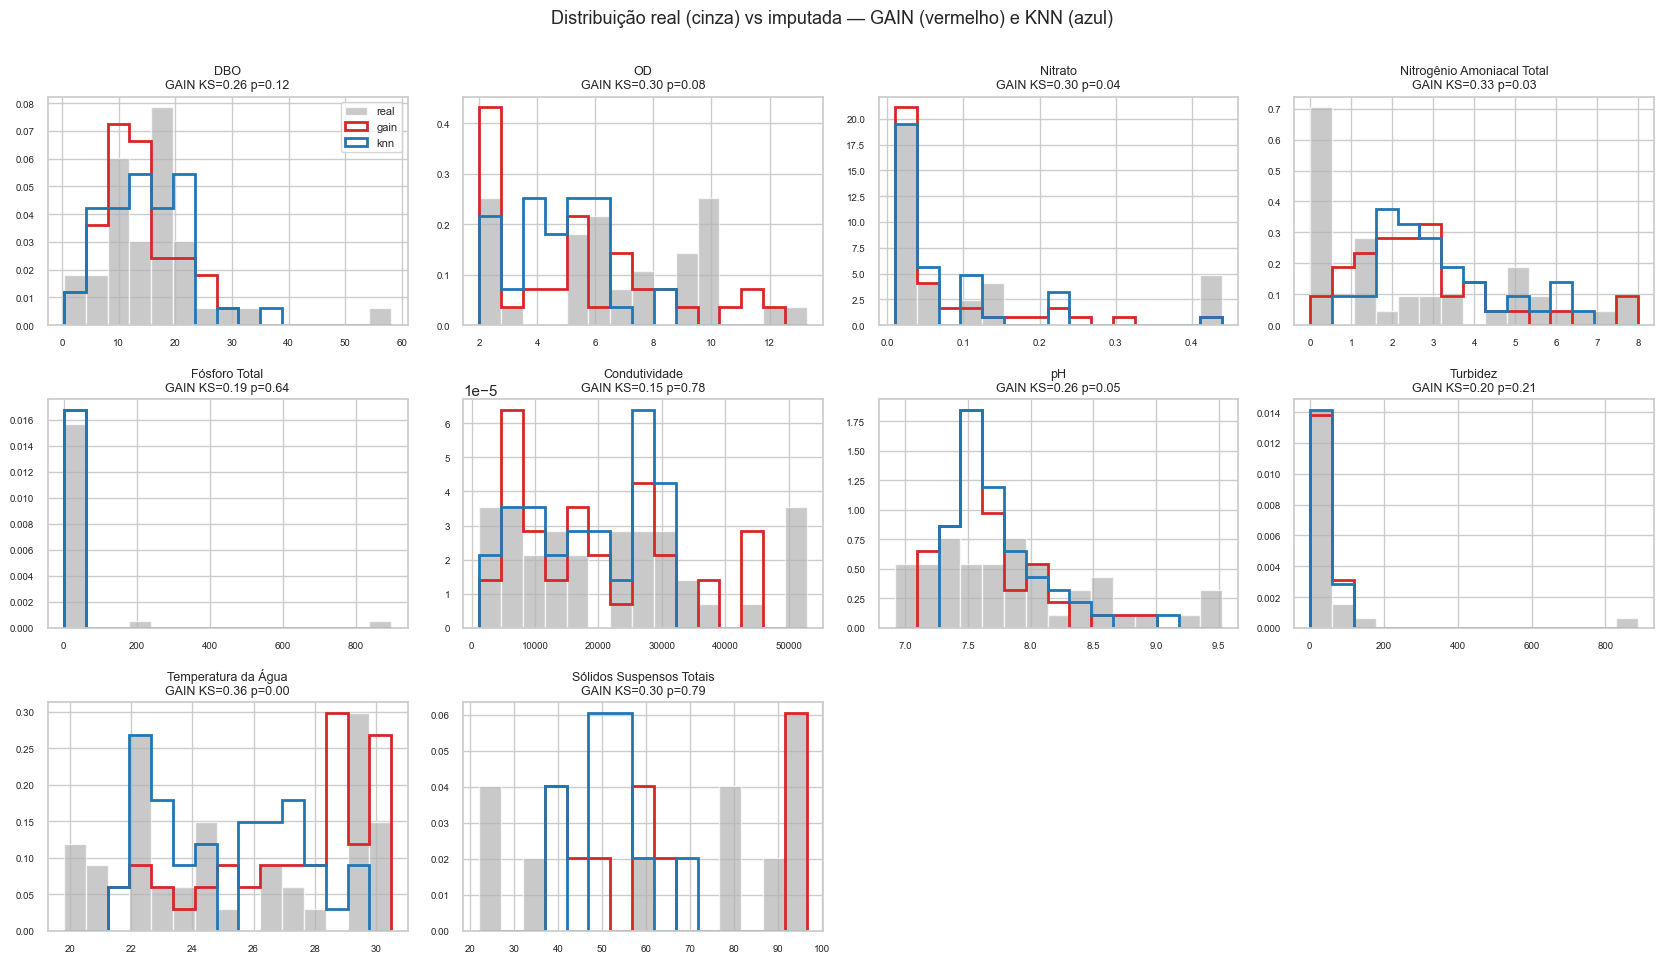

figura salva: ks_histogramas.png


In [5]:
destaque = ["gain", "knn"]
cores = {"gain": "#d62728", "knn": "#1f77b4"}
ncol = 4; nrow = int(np.ceil(len(VARS_AVAL) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.2 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, var in zip(axes, VARS_AVAL):
    reais = longo[(longo.metodo == 'gain') & (longo.variavel == var)]["real"].to_numpy()
    lo, hi = np.percentile(reais, [1, 99])
    if hi <= lo: hi = lo + 1e-9
    bins = np.linspace(lo, hi, 16)
    ax.hist(np.clip(reais, lo, hi), bins=bins, density=True, color="0.7",
            alpha=0.7, label="real")
    for metodo in destaque:
        imp = longo[(longo.metodo == metodo) & (longo.variavel == var)]["imputado"].to_numpy()
        ax.hist(np.clip(imp, lo, hi), bins=bins, density=True, histtype="step",
                lw=2, color=cores[metodo], label=metodo)
    ks_g = ks_df[(ks_df.metodo == 'gain') & (ks_df.variavel == var)].iloc[0]
    ax.set_title(f"{var}\nGAIN KS={ks_g.KS_stat:.2f} p={ks_g.KS_pvalue:.2f}", fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes[len(VARS_AVAL):]:
    ax.axis("off")
axes[0].legend(fontsize=8)
fig.suptitle("Distribuição real (cinza) vs imputada — GAIN (vermelho) e KNN (azul)",
             y=1.002, fontsize=13)
fig.tight_layout()
fig.savefig(OUT_FIG / "ks_histogramas.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figura salva: {(OUT_FIG / 'ks_histogramas.png').name}")

## 6. ECDFs sobrepostas

ECDF real vs de cada método (todos os 8, GAIN em destaque). A **maior distância vertical**
entre a curva real e a de um método **é a estatística KS**. Aqui os baselines triviais
aparecem como **degraus quase verticais** (valores quase constantes → compressão extrema),
o contraste que os histogramas não mostram bem. Eixo-x cortado em 1–99% dos reais.

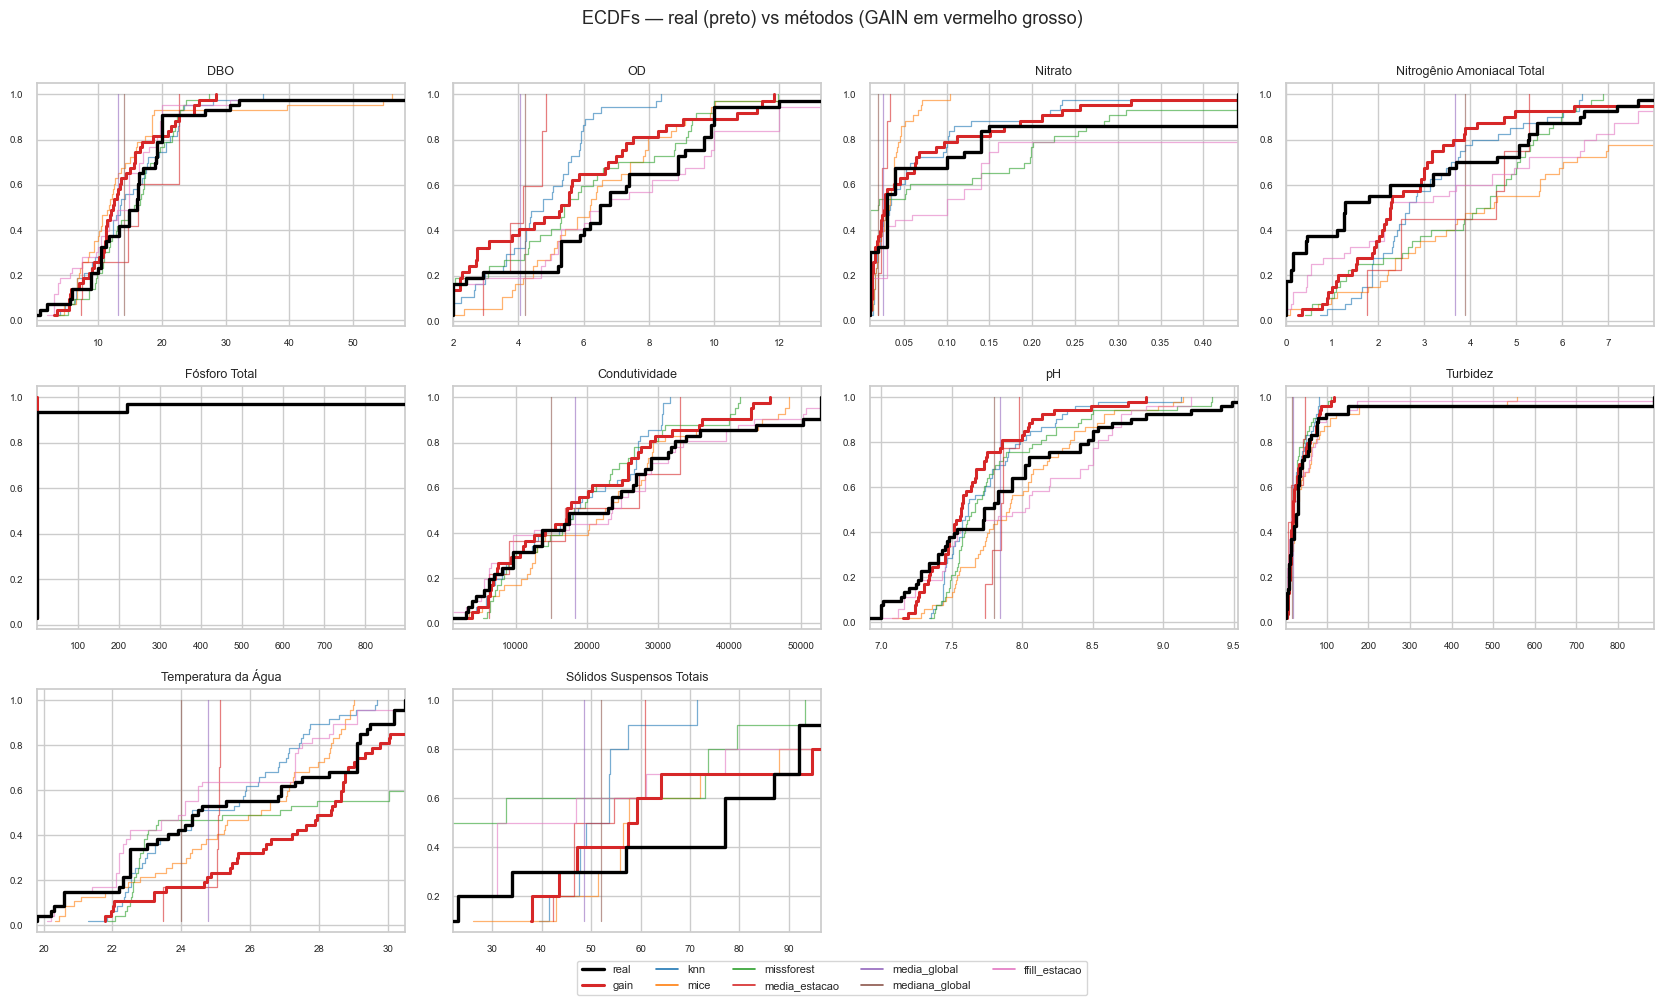

figura salva: ks_ecdfs.png


In [6]:
def ecdf(v):
    v = np.sort(v); return v, np.arange(1, len(v) + 1) / len(v)

paleta = {m: c for m, c in zip(BASELINES, sns.color_palette("tab10", len(BASELINES)))}
paleta["gain"] = "#d62728"
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.2 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, var in zip(axes, VARS_AVAL):
    reais = longo[(longo.metodo == 'gain') & (longo.variavel == var)]["real"].to_numpy()
    lo, hi = np.percentile(reais, [1, 99])
    xr, yr = ecdf(reais)
    ax.step(xr, yr, where="post", color="black", lw=2.4, label="real", zorder=5)
    for metodo in METODOS:
        imp = longo[(longo.metodo == metodo) & (longo.variavel == var)]["imputado"].to_numpy()
        xi, yi = ecdf(imp)
        ax.step(xi, yi, where="post", color=paleta[metodo],
                lw=(2.2 if metodo == "gain" else 0.9),
                alpha=(1.0 if metodo == "gain" else 0.6),
                label=metodo if metodo == "gain" else None, zorder=4 if metodo=="gain" else 2)
    ax.set_xlim(lo, hi)
    ax.set_title(var, fontsize=9); ax.tick_params(labelsize=7)
for ax in axes[len(VARS_AVAL):]:
    ax.axis("off")
handles = [plt.Line2D([], [], color="black", lw=2.4, label="real"),
           plt.Line2D([], [], color="#d62728", lw=2.2, label="gain")]
handles += [plt.Line2D([], [], color=paleta[m], lw=1.2, label=m) for m in BASELINES]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("ECDFs — real (preto) vs métodos (GAIN em vermelho grosso)", y=1.002, fontsize=13)
fig.tight_layout()
fig.savefig(OUT_FIG / "ks_ecdfs.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figura salva: {(OUT_FIG / 'ks_ecdfs.png').name}")

## 7. Comparação de p-valores: `-log10(p)` por variável e método

`-log10(p)` cresce quando a distribuição imputada **difere** da real (pior). A linha
tracejada marca `-log10(0.05) ≈ 1.30`: **barras acima dela rejeitam H₀** (distribuições
diferentes). Queremos barras **baixas** (GAIN idealmente abaixo da linha).

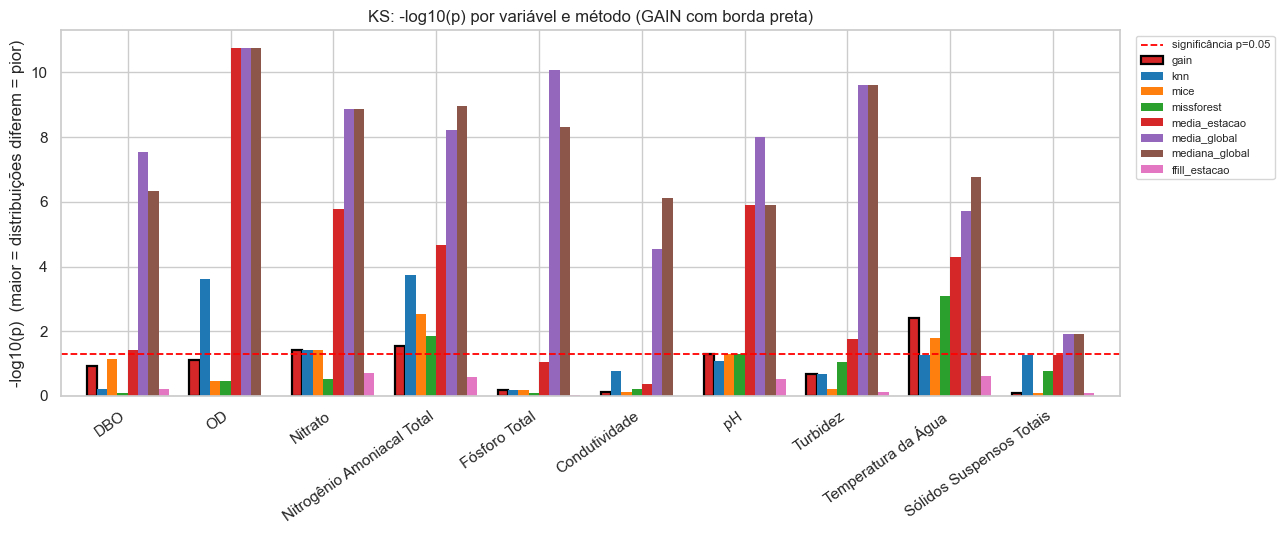

figura salva: ks_barras_pvalue.png


In [7]:
ks_df["neglog10_p"] = -np.log10(ks_df["KS_pvalue"].clip(lower=1e-300))
mat = (ks_df.pivot(index="variavel", columns="metodo", values="neglog10_p")
       .reindex(index=VARS_AVAL, columns=METODOS))
fig, ax = plt.subplots(figsize=(13, 5.5))
mat.plot(kind="bar", ax=ax, width=0.8,
         color=[paleta[m] for m in METODOS], edgecolor="none")
for bars, met in zip(ax.containers, METODOS):
    if met == "gain":
        for b in bars: b.set_edgecolor("black"); b.set_linewidth(1.6)
ax.axhline(-np.log10(0.05), ls="--", color="red", lw=1.3,
           label="significância p=0.05")
ax.set_ylabel("-log10(p)  (maior = distribuições diferem = pior)")
ax.set_xlabel(""); ax.tick_params(axis="x", rotation=35)
for lbl in ax.get_xticklabels(): lbl.set_ha("right")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_title("KS: -log10(p) por variável e método (GAIN com borda preta)")
fig.tight_layout()
fig.savefig(OUT_FIG / "ks_barras_pvalue.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figura salva: {(OUT_FIG / 'ks_barras_pvalue.png').name}")

## 8. Síntese — fidelidade distribucional

In [8]:
g = ks_df[ks_df.metodo == "gain"]
n_preserva = int(g["preserva_dist_5pct"].sum())
piores = g.sort_values("KS_pvalue").head(3)
comprime = g[g["sd_ratio"] < 0.8].sort_values("sd_ratio")
knn_preserva = int(ks_df[(ks_df.metodo=="knn")]["preserva_dist_5pct"].sum())

print("SÍNTESE — DISTRIBUIÇÕES (KS, test set)")
print("=" * 60)
print(f"GAIN preserva a distribuição (p>0.05) em ... {n_preserva}/{len(VARS_AVAL)} variáveis")
print(f"KNN (melhor baseline) preserva em .......... {knn_preserva}/{len(VARS_AVAL)}")
print(f"sd_ratio mediano da GAIN ................... {g['sd_ratio'].median():.3f}"
      f"  ({'compressão' if g['sd_ratio'].median()<1 else 'sem compressão'})")
print(f"\nVariáveis onde a GAIN mais difere (menor p):")
for _, r in piores.iterrows():
    print(f"   - {r['variavel']:28s} KS={r['KS_stat']:.2f} p={r['KS_pvalue']:.3g} "
          f"sd_ratio={r['sd_ratio']:.2f} (n={r['n']})")
print(f"\nVariáveis com compressão marcada (sd_ratio<0.8): "
      f"{list(comprime['variavel']) if len(comprime) else 'nenhuma'}")
print("\nComparação com o PIBIC anterior (GAN comprimiu: KS p<0.001 em TODAS):")
print(f"   Aqui a GAIN NÃO é rejeitada em {n_preserva}/{len(VARS_AVAL)} variáveis — melhora")
print("   clara sobre o quadro do PIBIC, RESSALVANDO o baixo n (pouco poder do KS).")

SÍNTESE — DISTRIBUIÇÕES (KS, test set)
GAIN preserva a distribuição (p>0.05) em ... 6/10 variáveis
KNN (melhor baseline) preserva em .......... 7/10
sd_ratio mediano da GAIN ................... 0.742  (compressão)

Variáveis onde a GAIN mais difere (menor p):
   - Temperatura da Água          KS=0.36 p=0.00397 sd_ratio=0.90 (n=47)
   - Nitrogênio Amoniacal Total   KS=0.33 p=0.0286 sd_ratio=0.89 (n=40)
   - Nitrato                      KS=0.30 p=0.0387 sd_ratio=0.70 (n=43)

Variáveis com compressão marcada (sd_ratio<0.8): ['Fósforo Total', 'Turbidez', 'DBO', 'pH', 'Nitrato', 'Condutividade']

Comparação com o PIBIC anterior (GAN comprimiu: KS p<0.001 em TODAS):
   Aqui a GAIN NÃO é rejeitada em 6/10 variáveis — melhora
   clara sobre o quadro do PIBIC, RESSALVANDO o baixo n (pouco poder do KS).


### Leitura

O KS aqui é uma checagem de **fidelidade distribucional**, complementar ao erro pontual do
nb01: mede se a GAIN reproduz a **forma** da distribuição (dispersão e caudas), não só a
posição. Dois cuidados na interpretação:

1. **Poder do teste.** Com 10–54 células por variável, `p` alto pode ser falta de evidência,
   não igualdade. Por isso o `sd_ratio` é o diagnóstico honesto de compressão — cruze as
   duas colunas antes de concluir.
2. **Contraste com o PIBIC.** Lá a GAN foi rejeitada em todas as variáveis; se aqui a GAIN
   é preservada na maioria, o termo supervisionado `beta` e o condicionamento ajudaram —
   mas a comparação não é perfeitamente pareada (dataset, n e protocolo diferentes).

Cruzando com o diagnóstico da Etapa 4 (encolhimento de caudas em SST/Turbidez), as ECDFs
devem mostrar a GAIN um pouco mais "íngreme" que o real nessas variáveis.

**Próximo notebook:** `03_correlacoes.ipynb` (estrutura de correlação real × imputada,
norma de Frobenius).